In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

In [3]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

In [4]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

In [5]:
from langchain_core.prompts import ChatPromptTemplate

In [49]:
class State(TypedDict):
  application: str
  experience_level: str
  skill_match: str
  response: str


In [50]:
workflow = StateGraph(State)


In [51]:
def categorize_experience(state: State):
  print("\nCategorizing the experience level of candidate: ")
  prompt = ChatPromptTemplate.from_template("Based on the following job application, categorize the candidate as 'Entry-level','Mid-level' or 'Senior-level' "
   "Application : {application}")
  chain = prompt | llm 
  experience_level = chain.invoke({"application": state['application']}).content
  print(f"Experience Level: {experience_level}")
  return {"experience_level": experience_level}
  

def assess_skillset(state:State)->State:
  print("\nAssessing the skillset of candidate : ")
  prompt = ChatPromptTemplate.from_template(
    "Based on the job application for a Python Developer, assess the candidate's skillset"
    "Respond with either 'Match' or 'No Match'"
    "Application : {application}"
  )
  chain = prompt | llm
  skill_match = chain.invoke({"application":state["application"]}).content
  print(f"Skill Match : {skill_match}")
  return {"skill_match" : skill_match}

def schedule_hr_interview(state: State)->State:
  print("\nScheduling the interview : ")
  return {"response" : "Candidate has been shortlisted for an HR interview."}

def escalate_to_recruiter(state:State)->State:
  print("Escalating to recruiter")
  return {"response" : "Candidate has senior-level experience but doesn't match job skills."}

def reject_application(state:State)->State:
  print("Sending rejection email")
  return {"response" : "Candidate doesn't meet JD and has been rejected."}


  
  
  

In [52]:
workflow.add_node("categorize_experience",categorize_experience)
workflow.add_node("schedule_hr_interview",schedule_hr_interview)
workflow.add_node("escalate_to_recruiter",escalate_to_recruiter)
workflow.add_node("reject_application",reject_application)
workflow.add_node("assess_skillset",assess_skillset)


In [53]:
def route_app(state: dict) -> str:
    raw_skill = str(state.get("skill_match", "")).lower()

    # Extract intent instead of exact match
    if "no match" in raw_skill:
        return "reject_application"

    if "match" in raw_skill:
        exp = str(state.get("experience_level", "")).lower()

        if "senior" in exp:
            return "escalate_to_recruiter"

        return "schedule_hr_interview"

    # fallback
    return "reject_application"


In [54]:
workflow.add_edge("categorize_experience","assess_skillset")
workflow.add_conditional_edges("assess_skillset",
                               route_app)

In [55]:
workflow.add_edge(START,"categorize_experience")

workflow.add_edge("escalate_to_recruiter",END)
workflow.add_edge("reject_application",END)
workflow.add_edge("schedule_hr_interview",END)

In [56]:
app = workflow.compile()

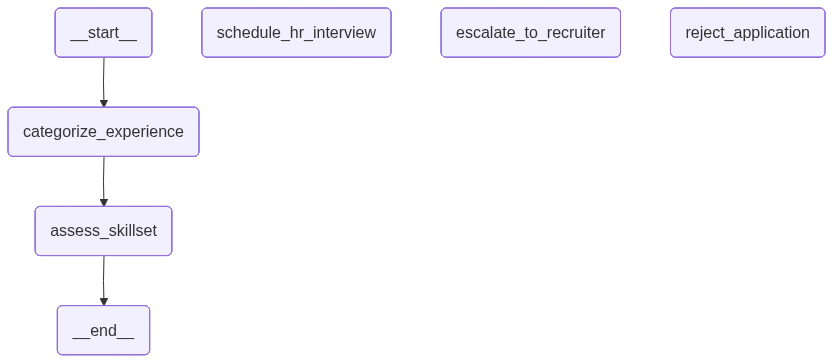

In [57]:
display(Image(app.get_graph().draw_mermaid_png()))

In [58]:
def run_candidate_screening(application : str):
  res = app.invoke({"application":application})
  return {
    "experience_level" : res['experience_level'],
    "skill_match": res['skill_match'],
    "response" : res["response"]
  }

In [59]:
application_text = "I have 10 years of experience in software engineering with expertise in JAVA"
res = run_candidate_screening(application_text)
print("\n\nComputed Results:")
print(f"Application: {application_text}")
print(f"Experience Level: {res['experience_level']}")
print(f"Skill Match : {res['skill_match']}")
print(f"Response: {res['response']}")



Categorizing the experience level of candidate: 
Experience Level: Based on the information provided in the job application, I would categorize the candidate as 'Mid-level'. 

Here's the reasoning behind this categorization:

- The candidate has 10 years of experience, which is more than the typical 5-7 years required for a mid-level position.
- The candidate mentions expertise in a specific technology, JAVA, indicating a certain level of specialization and depth in their knowledge.
- However, the lack of information about leadership roles, project management experience, or advanced skills (e.g., architecture, technical lead, etc.) suggests that they may not be at the senior-level.

Therefore, based on the information provided, a mid-level categorization seems to be the most accurate.

Assessing the skillset of candidate : 
Skill Match : No Match

The application mentions expertise in JAVA, but the job position is for a Python Developer. While it's possible for a developer to be profi

In [60]:
application_text = "I have 1 years of experience in software engineering with expertise in JAVA"
res = run_candidate_screening(application_text)
print("\n\nComputed Results:")
print(f"Application: {application_text}")
print(f"Experience Level: {res['experience_level']}")
print(f"Skill Match : {res['skill_match']}")
print(f"Response: {res['response']}")


Categorizing the experience level of candidate: 
Experience Level: Based on the job application, I would categorize the candidate as 'Mid-level'. 

The reason for this is:

- The candidate has 1 year of experience, which suggests they have some experience under their belt but are not yet at a senior level with multiple years of experience.
- They mention expertise in JAVA, which implies a level of proficiency and skills development beyond entry-level, but not necessarily at a senior level where they would have expertise in multiple technologies or languages.

This places the candidate in a mid-level category, likely with a junior or assistant engineer role, who has gained some experience but is still developing their skills and expertise.

Assessing the skillset of candidate : 
Skill Match : No Match

The candidate has experience in software engineering, but it's not clear if they have any experience with Python. Additionally, their expertise is in Java, not Python. Python is a key sk

In [61]:
application_text = (
    "I am a final-year B.Tech student with 2 years of hands-on experience "
    "working on web applications. I have strong skills in Python, Flask, "
    "SQL, and basic machine learning. I have built real-world projects, "
    "worked in teams, and am eager to grow in a software engineering role."
)
res = run_candidate_screening(application_text)
print("\n\nComputed Results:")
print(f"Application: {application_text}")
print(f"Experience Level: {res['experience_level']}")
print(f"Skill Match : {res['skill_match']}")
print(f"Response: {res['response']}")


Categorizing the experience level of candidate: 
Experience Level: Based on the job application, I would categorize the candidate as 'Entry-level'. 

Here's why:

- The candidate is a final-year B.Tech student, which indicates they are close to completing their undergraduate degree and are likely to be entering the workforce.
- They have 2 years of hands-on experience, which is a good start but still relatively limited compared to more experienced professionals.
- Although they have strong skills in several programming languages and technologies, their experience is mostly in academia and possibly internships, which is common for entry-level candidates.
- They have a desire to grow in a software engineering role, which suggests they are looking for opportunities to learn and develop their skills further.

Overall, the candidate's experience, skills, and education level are consistent with an entry-level candidate.

Assessing the skillset of candidate : 
Skill Match : Match. 

The cand

In [62]:
application_text = (
    """KATASANI VENKATA PANDU RANGA REDDY

228r1a6789@gmail.com |
 
(+91)9573860088
 
|
 
LinkedIn

OBJECTIVE
:

Motivated Computer Science Engineering student specializing in Data Science, with strong skills in software
development, GenAI, and problem-solving. Seeking opportunities to apply technical expertise and contribute
to innovative solutions.

EDUCATION:

CMR Engineering College:
 
Computer Science Engineering
 
Data Science | CGPA: 9.31 | 2026

Narayana Junior College:
 
XII (TSBIE) | 97.1% | 2022

Sri Sai Saraswathi Vidyaniketan School:
 
X (TSBSE) | CGPA: 10 | 2020

SKILLS:

Programming:
 
Python, C++

Web:
 
HTML, CSS, Flask, Javascript, React

Databases:
 
MySQL

Core CS
: Data Structures & Algorithms, OOPS, DBMS, CN, OS

AI/ML:
 
LangChain, LangGraph, Prompt Engineering, Machine Learning (Basics), RAG Model, MCP

Soft Skills:
 
Adaptability, Teamwork, Communication, Leadership

PROJECTS: 
Walmart Sales Data Analysis | MySQL
Analyzed 1,000+ Walmart transactions to identify sales trends, top-performing products, and
customer behavior, using advanced SQL queries, feature engineering, and EDA to generate
actionable business insights.
Automated Recruitment System | LangGraph, Python
Designed and implemented a modular recruitment workflow system with clearly defined stages for
experience categorization, skill assessment, and hiring decisions. Enabled automated routing of
candidates to HR interviews, recruiter review, or rejection, improving process efficiency and ensuring
scalable, rule-based hiring operations. 
LCEL Language Translator App | Python, Streamlit, LangChain (LCEL), Groq
Built a real-time multilingual translation app using LCEL
 
(prompt →
 
model
 
→
 
parser pipeline) with
Groq’s Gemma2
-9b-It for fast, context-aware translations. Designed an interactive UI, secured API
keys via .env, and optimized prompts to achieve high translation accuracy while preserving tone and
punctuation.

ACHIEVEMENTS:
Secured
 
3rd Position
 
for Outstanding Academic Performance in 2022-23
 
Organized college tech fest attended by
 
300+ students
, managing logistics and coordination
Earned a Gold Badge in Problem Solving on Hacker Rank.
Completed a DSA course from Smart Interviews and earned the Diamond Badge, ranking in the top 50
out of
 
400+ participants
 
in the final contest, demonstrating strong algorithmic and problem-solving
skills.

CERTIFICATIONS:

AI For India 2.0 (2023):
 
Participated in a national AI initiative impacting
 
1M+
 
learners across India

IBM Skills Build
: Completed a CSRBOX Micro-Internship on Data Science, focusing on practical
data science skills and applications."""

)
res = run_candidate_screening(application_text)
print("\n\nComputed Results:")
print(f"Application: {application_text}")
print(f"Experience Level: {res['experience_level']}")
print(f"Skill Match : {res['skill_match']}")
print(f"Response: {res['response']}")


Categorizing the experience level of candidate: 
Experience Level: Based on the provided job application, I would categorize the candidate as 'Entry-level' for the following reasons:

1. **Education**: The candidate is still a student and is expected to graduate in 2026. This indicates that they have limited work experience.
2. **Work Experience**: There is no mention of any full-time work experience or significant internships that would indicate a level of maturity and responsibility.
3. **Skills**: While the candidate has a strong set of technical skills, they are mostly related to Data Science, AI, and programming, which are typical skills for a recent graduate or an early-career professional.
4. **Projects**: The candidate has completed several projects, but they are mostly academic in nature and not necessarily indicative of real-world work experience.
5. **Achievements**: While the candidate has achieved some notable results in academic competitions and certifications, these are